<a href="https://colab.research.google.com/github/IvanVelezQu/Estructuras-base-de-datos/blob/main/Problema_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import math
import pandas as pd # Added import for pandas

class NodoKD:
    def __init__(self, puntos, izquierda=None, derecha=None):
        self.punto = puntos
        self.izquierda = izquierda
        self.derecha = derecha

def construir_kdtree(puntos, profundidad=0):
    if not puntos:
        return None

    # k = número de dimensiones (soporta 2D, 3D, ND)
    k = len(puntos[0])
    eje = profundidad % k

    # Ordenar los puntos por el eje actual y encontrar la mediana
# IMPORTANTE: El ordenamiento previo (sort) es estrictamente necesario.
    # Si los datos están crudos (ej. a = [2, 1, 3]), el punto medio espacial (índice 1) no es la mediana.
    # Al ordenar (a = [1, 2, 3]), se ataca las dos problematicas de a funcion:
    # 1. El índice central contiene la mediana real (balance perfecto).
    # 2. El arreglo queda agrupado para separar fácilmente la rama izquierda de la derecha.
    puntos.sort(key=lambda x: x[eje])
    mediana_idx = len(puntos) // 2

    # El nodo almacena el punto y construye recursivamente sus ramas
    nodo = NodoKD(puntos[mediana_idx])
    nodo.izquierda = construir_kdtree(puntos[:mediana_idx], profundidad + 1)
    nodo.derecha = construir_kdtree(puntos[mediana_idx + 1:], profundidad + 1)

    return nodo

def distancia_euclidiana(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

In [12]:
#Busqueda en un Radio
def busqueda_radio(nodo, objetivo, radio, profundidad=0, resultados=None):
  if resultados is None:
    resultados = []

  if nodo is None:
    return resultados

  #Aqui se anade el punto si esta dentro del radio
  distancia = distancia_euclidiana(nodo.punto, objetivo)
  if distancia <= radio:
    resultados.append(nodo.punto)

  K = len(objetivo)
  eje = profundidad % K

  #Se determina en que parte del plano de division esta el objetivo
  diferencia_eje = objetivo[eje] - nodo.punto[eje]

  #se explora la rama mas cercana primero
  rama_cercana = nodo.izquierda if diferencia_eje < 0 else nodo.derecha
  rama_lejana = nodo.derecha if diferencia_eje < 0 else nodo.izquierda
  busqueda_radio(rama_cercana, objetivo, radio, profundidad + 1, resultados)

  if abs(diferencia_eje) <= radio:
    busqueda_radio(rama_lejana, objetivo, radio, profundidad + 1, resultados)

  return resultados

In [13]:
#Vecino mas cercano
def vecino_mas_cercano(nodo, objetivo, profundidad=0, mejor=None, mejor_dist=float('inf')):
    if nodo is None:
        return mejor, mejor_dist

    # Actualizar el mejor punto si el actual es más cercano
    dist = distancia_euclidiana(nodo.punto, objetivo)
    if dist < mejor_dist:
        mejor = nodo.punto
        mejor_dist = dist

    k = len(objetivo)
    eje = profundidad % k
    diferencia_eje = objetivo[eje] - nodo.punto[eje]

    rama_cercana = nodo.izquierda if diferencia_eje < 0 else nodo.derecha
    rama_lejana = nodo.derecha if diferencia_eje < 0 else nodo.izquierda

    mejor, mejor_dist = vecino_mas_cercano(rama_cercana, objetivo, profundidad + 1, mejor, mejor_dist)

    # Solo exploramos la rama lejana si el hiperplano está más cerca que nuestra mejor distancia actual
    if abs(diferencia_eje) < mejor_dist:
        mejor, mejor_dist = vecino_mas_cercano(rama_lejana, objetivo, profundidad + 1, mejor, mejor_dist)

    return mejor, mejor_dist

In [14]:
#Implementacion de la fuerza bruta
# Para esta funcion se aplica una comparacion del objetivo contra todos los puntos 1 por 1
def fuerza_bruta_radio(puntos, objetivo, radio):
    return [p for p in puntos if distancia_euclidiana(p, objetivo) <= radio]

def fuerza_bruta_cercano(puntos, objetivo):
    mejor_punto = None
    mejor_dist = float('inf')
    for p in puntos:
        dist = distancia_euclidiana(p, objetivo)
        if dist < mejor_dist:
            mejor_dist = dist
            mejor_punto = p
    return mejor_punto, mejor_dist

In [9]:
import time
import random

tamaños_de_prueba = [10, 50, 100, 500, 1000, 5000, 10000,100000]
punto_prueba = (5000, 5000)

print("COMPARATIVA: VECINO MÁS CERCANO")
print(f"{'N Datos':<10} | {'Fuerza Bruta':<15} | {'Árbol KD':<15} | {'Ganador'}")
print("-" * 60)

for N in tamaños_de_prueba:
    # 1. Preparar datos
    puntos_test = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(N)]
    raiz_test = construir_kdtree(puntos_test.copy())

    # 2. Medir Fuerza Bruta
    inicio = time.perf_counter()
    fuerza_bruta_cercano(puntos_test, punto_prueba) #función de fuerza bruta
    tiempo_fb = time.perf_counter() - inicio

    # 3. Medir Árbol KD
    inicio = time.perf_counter()
    vecino_mas_cercano(raiz_test, punto_prueba)
    tiempo_kd = time.perf_counter() - inicio

    # 4. Resultados
    ganador = "Árbol KD" if tiempo_kd < tiempo_fb else "Fuerza Bruta"
    print(f"{N:<10} | {tiempo_fb:.6f}s      | {tiempo_kd:.6f}s      | {ganador}")

COMPARATIVA: VECINO MÁS CERCANO
N Datos    | Fuerza Bruta    | Árbol KD        | Ganador
------------------------------------------------------------
10         | 0.000040s      | 0.000014s      | Árbol KD
50         | 0.000059s      | 0.000028s      | Árbol KD
100        | 0.000099s      | 0.000017s      | Árbol KD
500        | 0.000465s      | 0.000047s      | Árbol KD
1000       | 0.001688s      | 0.000047s      | Árbol KD
5000       | 0.004660s      | 0.000085s      | Árbol KD
10000      | 0.009184s      | 0.000034s      | Árbol KD
100000     | 0.091204s      | 0.000085s      | Árbol KD


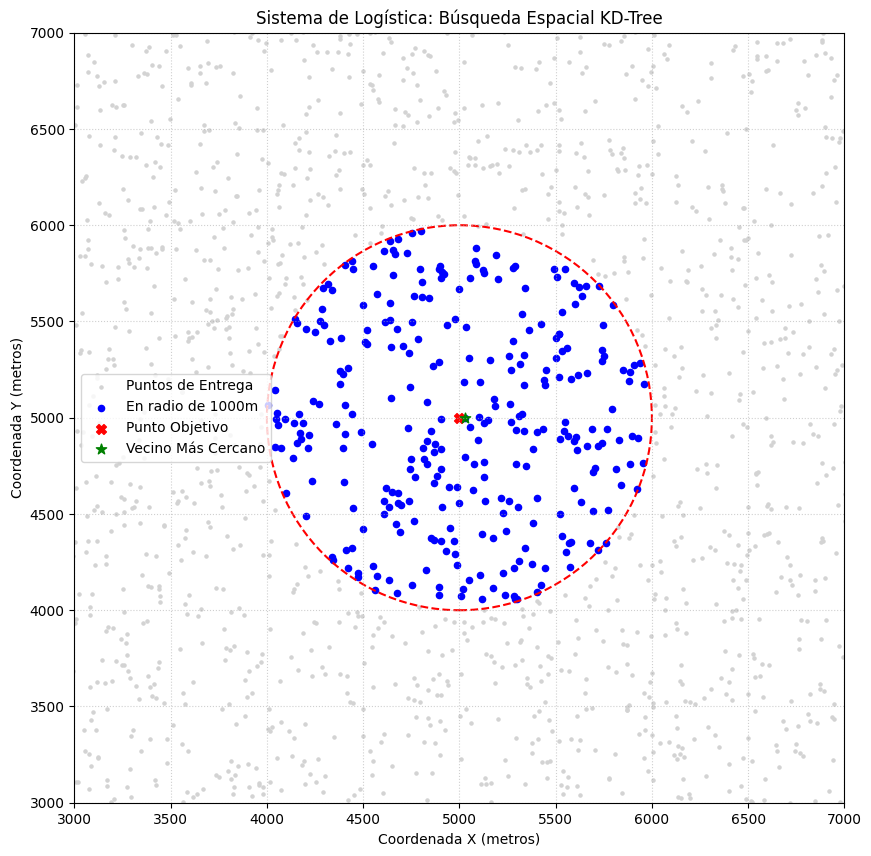

In [10]:
#Graficas para verificacion visual
import random
import matplotlib.pyplot as plt

# 1. Generar datos estáticos (10,000 puntos en 2D para visualización)
random.seed(42) # Semilla fija para datos estáticos consistentes
puntos_entrega = [(random.uniform(0, 10000), random.uniform(0, 10000)) for _ in range(10000)]

# 2. Construir el árbol
raiz_kd = construir_kdtree(puntos_entrega.copy())

# 3. Definir consulta
punto_objetivo = (5000, 5000)
radio_busqueda = 1000

# 4. Ejecutar búsquedas KD-Tree
puntos_en_radio = busqueda_radio(raiz_kd, punto_objetivo, radio_busqueda)
el_mas_cercano, dist_cercano = vecino_mas_cercano(raiz_kd, punto_objetivo)

# (Opcional) Puedes ejecutar fuerza bruta aquí para hacer un assert y validar
# assert sorted(puntos_en_radio) == sorted(fuerza_bruta_radio(puntos_entrega, punto_objetivo, radio_busqueda))

# 5. Visualización
fig, ax = plt.subplots(figsize=(10, 10))

# Extraer coordenadas para el gráfico (desempaquetar listas de tuplas)
X, Y = zip(*puntos_entrega)
rx, ry = zip(*puntos_en_radio) if puntos_en_radio else ([], [])

# Dibujar todos los puntos (gris claro)
ax.scatter(X, Y, c='lightgray', s=5, label='Puntos de Entrega')

# Dibujar puntos dentro del radio (azul)
ax.scatter(rx, ry, c='blue', s=20, label=f'En radio de {radio_busqueda}m')

# Dibujar el punto objetivo (rojo) y el círculo del radio
ax.scatter(*punto_objetivo, c='red', s=50, marker='X', label='Punto Objetivo')
circulo = plt.Circle(punto_objetivo, radio_busqueda, color='red', fill=False, linestyle='--', linewidth=1.5)
ax.add_patch(circulo)

# Dibujar el vecino más cercano (verde)
ax.scatter(*el_mas_cercano, c='green', s=60, marker='*', label='Vecino Más Cercano')

# Configurar límites para hacer un "zoom" visual cerca del objetivo
ax.set_xlim(punto_objetivo[0] - radio_busqueda * 2, punto_objetivo[0] + radio_busqueda * 2)
ax.set_ylim(punto_objetivo[1] - radio_busqueda * 2, punto_objetivo[1] + radio_busqueda * 2)

ax.set_aspect('equal')
plt.title("Sistema de Logística: Búsqueda Espacial KD-Tree")
plt.xlabel("Coordenada X (metros)")
plt.ylabel("Coordenada Y (metros)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()